# KYC-Based Risk Evaluation ML Pipeline (Random Forest)

This notebook demonstrates the end-to-end Machine Learning pipeline for building a Random Forest Classifier to detect fraudulent transactions using KYC and transactional data.

**Objective**:
- Identify suspicious financial transactions.
- Handle real-world data imbalance.
- Provide clear evaluation metrics.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import cross_val_score

import joblib
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Set display settings for pandas
pd.set_option('display.max_columns', 50)
np.random.seed(42)

## 1. Dataset Handling & Structural Inspection

In [2]:
# Load the dataset
filepath = 'Datasets/final_kyc_fraud_dataset.csv'
df = pd.read_csv(filepath)
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (50000, 28)


In [3]:
# Data Types
print(df.dtypes)

Transaction_ID                      str
User_ID                             str
Transaction_Amount              float64
Transaction_Type                    str
Timestamp                           str
Account_Balance                 float64
Device_Type                         str
Merchant_Category                   str
IP_Address_Flag                   int64
Previous_Fraudulent_Activity      int64
Daily_Transaction_Count           int64
Avg_Transaction_Amount_7d       float64
Failed_Transaction_Count_7d       int64
Card_Type                           str
Card_Age                          int64
Transaction_Distance            float64
Authentication_Method               str
Risk_Score                      float64
Is_Weekend                        int64
Fraud_Label                       int64
Age                               int64
Gender                              str
City                                str
Profession                          str
Monthly_Income_PKR                int64


In [4]:
# Check for null values
print(df.isnull().sum())

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
Age                             0
Gender                          0
City                            0
Profession                      0
Monthly_Income_PKR              0
Account_Type                    0
Account_Age_Years               0
Bank_Name                       0
dtype: int64


In [5]:
# Verify Label Distribution
print(df['Fraud_Label'].value_counts(normalize=True))

Fraud_Label
0    0.67866
1    0.32134
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis (EDA)

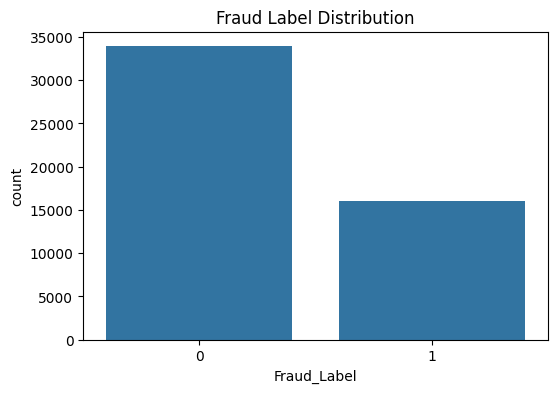

Percentage of fraudulent transactions: 32.13%


In [6]:
# Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Fraud_Label', data=df)
plt.title('Fraud Label Distribution')
plt.show()

fraud_pct = df['Fraud_Label'].mean() * 100
print(f"Percentage of fraudulent transactions: {fraud_pct:.2f}%")

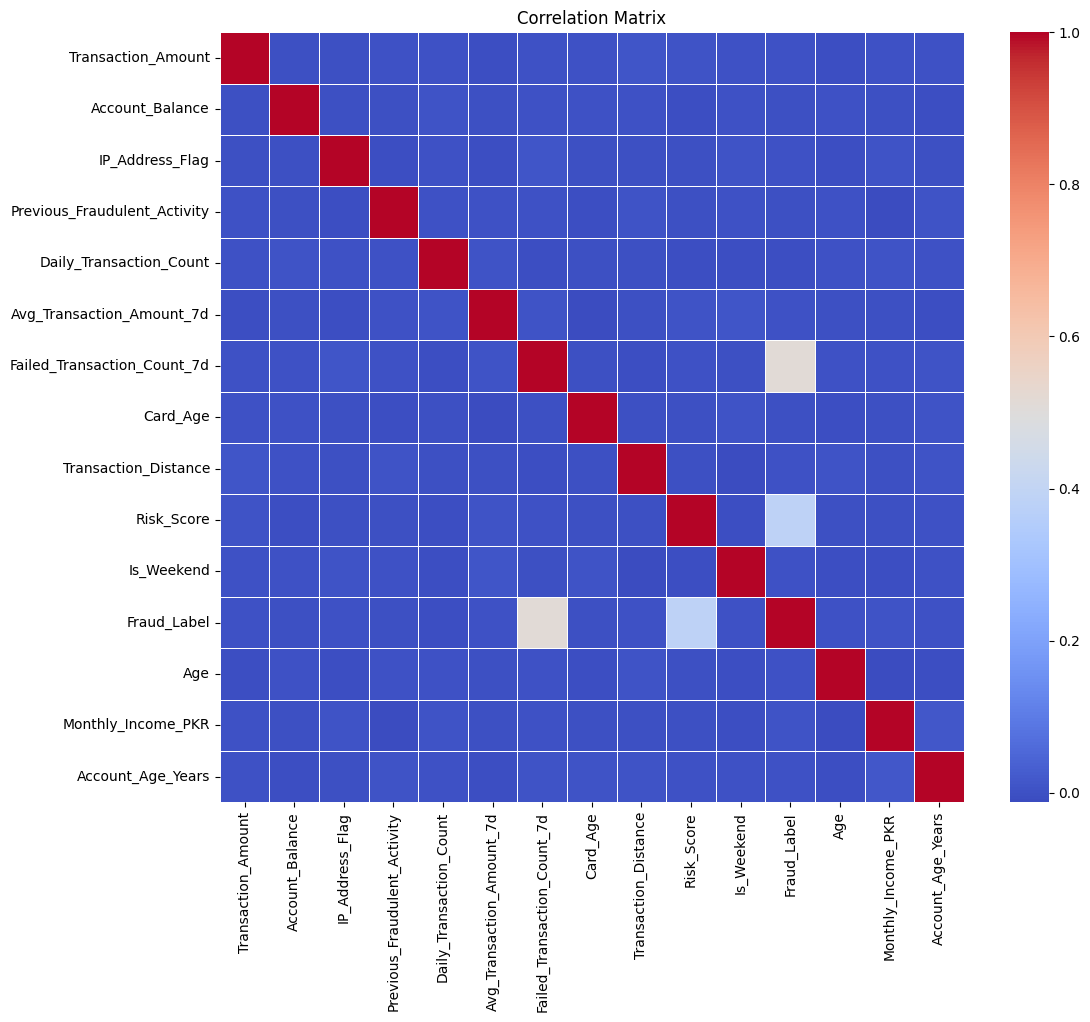

In [7]:
# Correlation Analysis (Numeric Features)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [8]:
# Top correlated features with Fraud_Label
target_corr = corr_matrix['Fraud_Label'].sort_values(ascending=False)
print("Top Positive Correlations:\n", target_corr.head(5))
print("\nTop Negative Correlations:\n", target_corr.tail(5))

Top Positive Correlations:
 Fraud_Label                    1.000000
Failed_Transaction_Count_7d    0.509871
Risk_Score                     0.385810
Monthly_Income_PKR             0.004714
IP_Address_Flag                0.003028
Name: Fraud_Label, dtype: float64

Top Negative Correlations:
 Transaction_Distance           -0.000116
Previous_Fraudulent_Activity   -0.000718
Card_Age                       -0.003120
Account_Balance                -0.003153
Daily_Transaction_Count        -0.007065
Name: Fraud_Label, dtype: float64


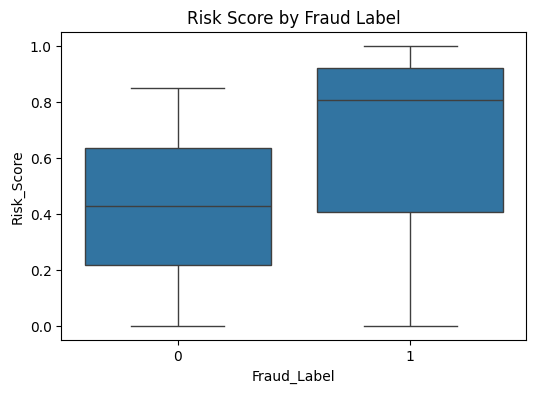

In [9]:
# Behavioral Patterns: Average Risk Score vs Fraud Label
plt.figure(figsize=(6, 4))
sns.boxplot(x='Fraud_Label', y='Risk_Score', data=df)
plt.title('Risk Score by Fraud Label')
plt.show()

## 3 & 4. Data Preprocessing & Feature Engineering

In [10]:
df_processed = df.copy()

# Feature Engineering 1: Extract Hour from Timestamp
df_processed['Timestamp'] = pd.to_datetime(df_processed['Timestamp'])
df_processed['Transaction_Hour'] = df_processed['Timestamp'].dt.hour
df_processed = df_processed.drop('Timestamp', axis=1)

# Feature Engineering 2: Amount to Balance Ratio
df_processed['Amount_to_Balance_Ratio'] = df_processed['Transaction_Amount'] / (df_processed['Account_Balance'] + 1e-5)

# Handle missing numeric values (Fill with median)
numeric_columns = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if df_processed[col].isnull().any():
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# Handle missing categorical values (Fill with mode)
categorical_columns = df_processed.select_dtypes(include=['object']).columns
for col in categorical_columns:
    if df_processed[col].isnull().any():
        df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])

# Drop IDs to prevent data leakage
cols_to_drop = ['Transaction_ID', 'User_ID', 'Risk_Score', 'Previous_Fraudulent_Activity']
df_processed = df_processed.drop([c for c in cols_to_drop if c in df_processed.columns], axis=1)

# Label Encoding for categorical variables
label_encoders = {}
categorical_columns = df_processed.select_dtypes(include=['object']).columns
for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

print("Preprocessing & Engineering Complete. Columns available:", df_processed.shape[1])

Preprocessing & Engineering Complete. Columns available: 25


In [11]:
# Separate features and target
X = df_processed.drop('Fraud_Label', axis=1)
y = df_processed['Fraud_Label']

# Feature Scaling (Standardization)
# Recommended so frontend gets uniform feature scales if used directly.
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train-test split (80-20 stratify for preserving fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 40000, Test size: 10000


## 5. Class Imbalance Handling

In [12]:
print("Original Train Class Distribution:")
print(y_train.value_counts())

# We will use SMOTE to handle the imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nResampled Train Class Distribution via SMOTE:")
print(y_train_resampled.value_counts())

# Justification: SMOTE synthetically generates minority samples in feature space, 
# ensuring the model doesn't overfit by simply looking at duplicate entries.

Original Train Class Distribution:
Fraud_Label
0    27146
1    12854
Name: count, dtype: int64



Resampled Train Class Distribution via SMOTE:
Fraud_Label
0    27146
1    27146
Name: count, dtype: int64


## 6. Model Training (Random Forest)

In [13]:
# Initialization and Hyperparameter Configuration (Tuned for Recall)
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=20, 
    class_weight='balanced',
    random_state=42, 
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 7. Model Evaluation Metrics

Accuracy:  0.8741
Precision: 0.9813
Recall:    0.6200
F1-Score:  0.7599
AUC Score: 0.8088696965615643

Confusion Matrix:
 [[6749   38]
 [1221 1992]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.91      6787
           1       0.98      0.62      0.76      3213

    accuracy                           0.87     10000
   macro avg       0.91      0.81      0.84     10000
weighted avg       0.89      0.87      0.86     10000



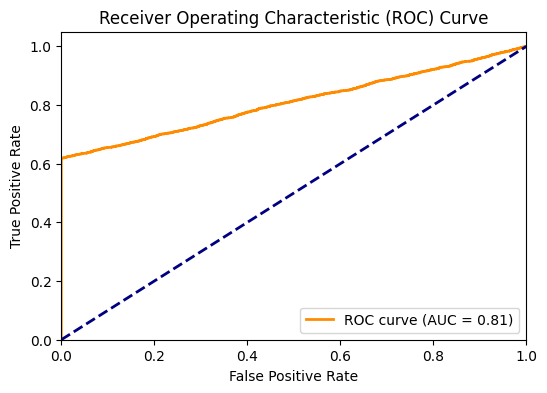

In [14]:
y_prob = rf_model.predict_proba(X_test)[:, 1]
# Custom threshold set to 0.3 to catch more fraud
y_pred = (y_prob > 0.3).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

if len(np.unique(y_test)) > 1:
    auc_score = roc_auc_score(y_test, y_prob)
else:
    auc_score = "N/A"

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC Score: {auc_score}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot ROC
if len(np.unique(y_test)) > 1:
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()


## Feature Importance

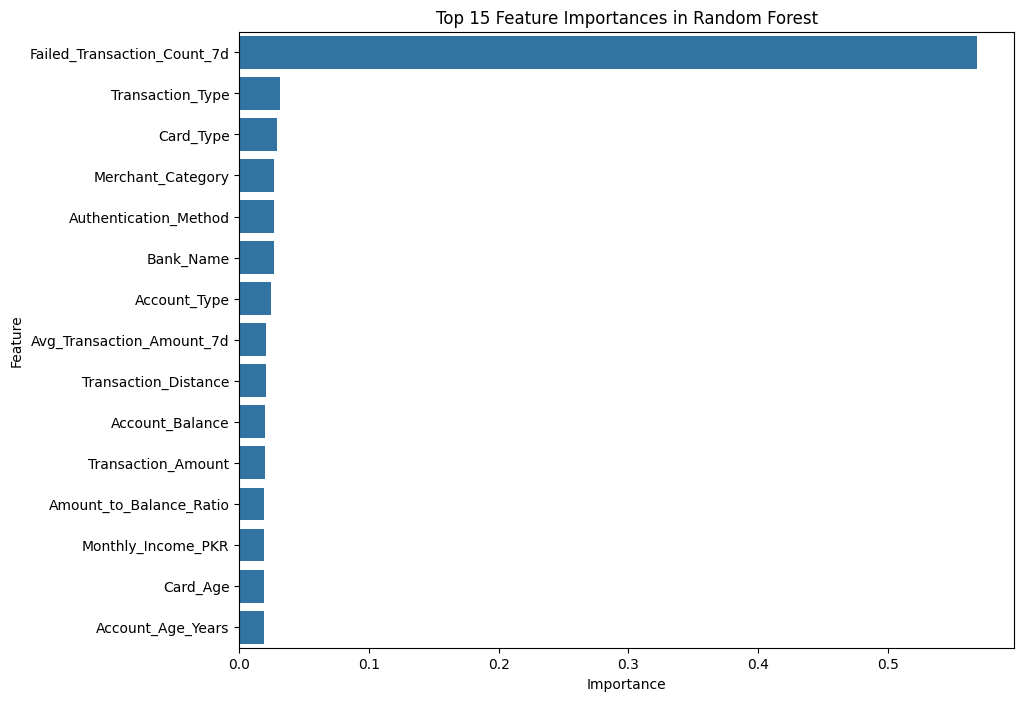

In [15]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Feature Importances in Random Forest')
plt.show()

In [16]:

# 8. Cross Validation Check
print("Executing 5-Fold Cross Validation...")
scores = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f"CV Accuracy Scores: {scores}")
print(f"Mean CV Accuracy: {scores.mean():.4f}")

# 9. Save Model
joblib.dump(rf_model, 'rf_model.pkl')
print("Model saved to 'rf_model.pkl'")


Executing 5-Fold Cross Validation...


CV Accuracy Scores: [0.8741 0.8791 0.8792 0.8785 0.8778]
Mean CV Accuracy: 0.8777


Model saved to 'rf_model.pkl'
